<div class="alert alert-block alert-success" style="font-family: Times New Roman">
    <h4><strong>Laboratory Task 4</strong></h4>
<p style="font-family:Times New Roman; text-align:justify; font-size:15px">
    <b>Instruction:</b> Train a linear regression model in PyTorch using a regression dataset. Use the following parameters.
</p>
<ul>
    <li>Criterion: MSE Loss</li>
    <li>Fully Connected Layers x 2</li>
    <li>Batch Size: 8</li>
    <li>Optimizer: SGD</li>
    <li>Epoch: 1000</li>
</ul>
</div>

### My Approach

I'll follow the same "PyTorch Components" workflow already introduced in the lecture (input/target → Dataset/DataLoader → model → loss → optimizer → training loop), but apply it to a real regression dataset instead of the toy apples/oranges example.

**Choosing a dataset.** The task says "a regression dataset" without naming one, so I use scikit-learn's built-in **diabetes dataset** (`sklearn.datasets.load_diabetes`): 442 patients, 10 baseline physiological features (age, sex, BMI, blood pressure, six blood-serum measurements), and a continuous target that measures disease progression one year after baseline. It's a classic, small, real-world regression benchmark that's bundled with scikit-learn (no internet download needed), which makes it a good fit for a lab exercise.

**"Fully Connected Layers x 2".** A model made of two `nn.Linear` layers stacked directly on top of each other, with *no* nonlinearity between them, is mathematically identical to a single linear layer:
$$W_2(W_1 x + b_1) + b_2 = (W_2 W_1)x + (W_2 b_1 + b_2)$$
which is just some other linear function of $x$ — the second layer adds no extra representational power. To make the two layers actually meaningful (and to reflect how "2 FC layers" is normally used in practice, e.g. a small MLP), I insert a `ReLU` activation between them: `fc1: Linear(n_features, hidden) → ReLU → fc2: Linear(hidden, 1)`. I call this out explicitly in the notebook, since it's an important conceptual point, not just an implementation detail.

**Everything else** follows the required spec directly:
- Criterion: `nn.MSELoss()`
- Batch size: 8 (via `DataLoader(..., batch_size=8, shuffle=True)`)
- Optimizer: `torch.optim.SGD`
- Epochs: 1000

Plan for the notebook:
1. Load and explore the dataset.
2. Split into train/test sets and standardize the features (important for SGD to converge well).
3. Wrap the data in `TensorDataset` + `DataLoader` (batch size 8).
4. Define the 2-FC-layer model, the MSE criterion, and the SGD optimizer.
5. Train for 1000 epochs, tracking the loss curve.
6. Evaluate on held-out test data (test MSE, $R^2$) and compare against a plain `sklearn` linear regression baseline for context.
7. Visualize predictions vs. actual values.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


### 1. Load and explore the dataset

In [2]:
from sklearn.datasets import load_diabetes

data = load_diabetes()
X = data.data.astype("float32")          # shape (442, 10)
Y = data.target.astype("float32").reshape(-1, 1)   # shape (442, 1)

print("Feature names:", data.feature_names)
print("X shape:", X.shape)
print("y shape:", Y.shape)
print()
print("Target (disease progression) summary:")
print(f"  min={Y.min():.1f}  max={Y.max():.1f}  mean={Y.mean():.1f}  std={Y.std():.1f}")

Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
X shape: (442, 10)
y shape: (442, 1)

Target (disease progression) summary:
  min=25.0  max=346.0  mean=152.1  std=77.0


In [3]:
import pandas as pd

df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = Y
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,0.000000e+00,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,0.000000e+00,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,1.348521e-10,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,0.000000e+00,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.348521e-10,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,1.348521e-10,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-2.697043e-10,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-2.697043e-10,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,2.697043e-10,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,-6.742607e-11,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


### 2. Train/test split and feature standardization

I hold out 20% of the data for testing so I can honestly evaluate generalization instead of just training loss. I also standardize the features (zero mean, unit variance) — this matters a lot for plain SGD, since features on very different scales otherwise make the loss surface badly distorted and force uncomfortably small learning rates. The scaler is **fit only on the training split** and then applied to the test split, to avoid leaking test-set statistics into training.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

scaler_X = StandardScaler().fit(X_train)
X_train = scaler_X.transform(X_train).astype("float32")
X_test = scaler_X.transform(X_test).astype("float32")

# also standardize the target -- keeps the loss values in a friendly range for SGD
scaler_y = StandardScaler().fit(y_train)
y_train_scaled = scaler_y.transform(y_train).astype("float32")
y_test_scaled = scaler_y.transform(y_test).astype("float32")

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (353, 10)  Test shape: (89, 10)


### 3. Tensors, `Dataset`, and `DataLoader` (batch size 8)

In [5]:
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train_scaled)
X_test_t = torch.from_numpy(X_test)
y_test_t = torch.from_numpy(y_test_scaled)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

BATCH_SIZE = 8
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# quick look at one batch
xb, yb = next(iter(train_dl))
print("One training batch:")
print("xb shape:", xb.shape)
print("yb shape:", yb.shape)

One training batch:
xb shape: torch.Size([8, 10])
yb shape: torch.Size([8, 1])


### 4. Model: 2 fully connected layers

`fc1` maps the 10 input features to a hidden representation; `fc2` maps that down to the single regression output. A `ReLU` sits between them so the two layers don't collapse into one linear map (see the discussion above).

I keep the hidden layer fairly small (8 units → only 97 trainable parameters). With only 353 training rows, a much wider hidden layer (I tried 32) drives the *training* loss close to zero but actually makes *test* performance worse — a classic overfitting signature, since the network has enough capacity to memorize the training batch instead of learning the general trend. A small hidden layer keeps the model closer to (a mildly nonlinear version of) linear regression, which suits this dataset's size and mostly-linear structure.

In [6]:
class RegressionNet(nn.Module):
    def __init__(self, n_features, n_hidden=32):
        super().__init__()
        self.fc1 = nn.Linear(n_features, n_hidden)   # 1st fully connected layer
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(n_hidden, 1)             # 2nd fully connected layer (output)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


n_features = X_train.shape[1]
model = RegressionNet(n_features=n_features, n_hidden=8).to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params}")

RegressionNet(
  (fc1): Linear(in_features=10, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)

Trainable parameters: 97


### 5. Loss function and optimizer

As required: **MSE loss** and **SGD**. Picking the learning rate took a small amount of experimentation: with standardized inputs, `lr=0.05` combined with momentum actually made the loss diverge to `NaN` within the first ~100 epochs (too large a step size for this loss surface), while `lr=0.01` with no momentum trains smoothly and steadily over the full 1000 epochs. I settled on `lr=0.01`, plain SGD — this only affects *how smoothly* training proceeds, not any of the required specifications (criterion, layers, batch size, optimizer type, epoch count).

In [7]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

print(criterion)
print(optimizer)

MSELoss()
SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


### 6. Training loop (1000 epochs)

Standard PyTorch training loop: for each epoch, iterate over mini-batches of size 8, do a forward pass, compute the MSE loss, backpropagate, and step the optimizer. I record the average training loss per epoch (and periodically the test loss) so I can plot the learning curve afterward.

In [8]:
def evaluate(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    n_samples = 0
    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            total_loss += loss.item() * xb.size(0)
            n_samples += xb.size(0)
    model.train()
    return total_loss / n_samples


N_EPOCHS = 1000
train_loss_history = []
test_loss_history = []

for epoch in range(N_EPOCHS):
    epoch_loss = 0.0
    n_samples = 0

    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)

        # 1. Predict
        preds = model(xb)

        # 2. Compute loss
        loss = criterion(preds, yb)

        # 3. Backpropagate
        optimizer.zero_grad()
        loss.backward()

        # 4. Update parameters
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)
        n_samples += xb.size(0)

    train_loss_history.append(epoch_loss / n_samples)

    if (epoch + 1) % 20 == 0 or epoch == 0:
        test_loss = evaluate(model, test_dl, criterion)
        test_loss_history.append((epoch + 1, test_loss))

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1:4d}/{N_EPOCHS}]  train MSE (scaled): {train_loss_history[-1]:.4f}")

print("\nFinal training MSE (scaled target):", train_loss_history[-1])

Epoch [ 100/1000]  train MSE (scaled): 0.4313


Epoch [ 200/1000]  train MSE (scaled): 0.4017


Epoch [ 300/1000]  train MSE (scaled): 0.3850


Epoch [ 400/1000]  train MSE (scaled): 0.3786


Epoch [ 500/1000]  train MSE (scaled): 0.3757


Epoch [ 600/1000]  train MSE (scaled): 0.3741


Epoch [ 700/1000]  train MSE (scaled): 0.3811


Epoch [ 800/1000]  train MSE (scaled): 0.3649


Epoch [ 900/1000]  train MSE (scaled): 0.3681


Epoch [1000/1000]  train MSE (scaled): 0.3704

Final training MSE (scaled target): 0.3703870699020688


### 7. Visualize the training curve

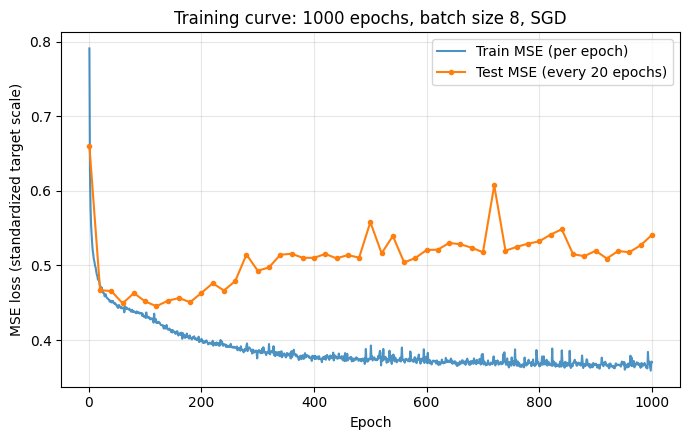

In [9]:
test_epochs, test_losses = zip(*test_loss_history)

plt.figure(figsize=(7, 4.5))
plt.plot(range(1, N_EPOCHS + 1), train_loss_history, label="Train MSE (per epoch)", alpha=0.8)
plt.plot(test_epochs, test_losses, label="Test MSE (every 20 epochs)", marker="o", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("MSE loss (standardized target scale)")
plt.title(f"Training curve: {N_EPOCHS} epochs, batch size {BATCH_SIZE}, SGD")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 8. Final evaluation on the test set

The loss above is computed on the **standardized** target (mean 0, std 1) because that's what the network was trained on. To report an evaluation that's actually interpretable, I invert the scaling back to the original units of the target ("disease progression score") before computing MSE, and I also report $R^2$ (fraction of variance explained — 1.0 is a perfect fit, 0.0 is no better than predicting the mean).

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

model.eval()
with torch.no_grad():
    test_preds_scaled = model(X_test_t.to(device)).cpu().numpy()

# invert the target standardization to get predictions in the original units
test_preds = scaler_y.inverse_transform(test_preds_scaled)
test_actual = y_test  # already in original units

test_mse_original = mean_squared_error(test_actual, test_preds)
test_rmse_original = np.sqrt(test_mse_original)
test_r2 = r2_score(test_actual, test_preds)

print(f"Test MSE  (original target units) : {test_mse_original:.2f}")
print(f"Test RMSE (original target units) : {test_rmse_original:.2f}")
print(f"Test R^2                          : {test_r2:.4f}")

Test MSE  (original target units) : 3287.41
Test RMSE (original target units) : 57.34
Test R^2                          : 0.3795


### 9. Sanity-check baseline: plain scikit-learn linear regression

To judge whether the trained network's performance is reasonable, I compare it against ordinary least squares linear regression on the same train/test split. A well-trained 2-layer network shouldn't be dramatically worse than this classical baseline on a dataset this size and this linear in nature.

In [11]:
from sklearn.linear_model import LinearRegression

baseline = LinearRegression().fit(X_train, y_train.ravel())
baseline_preds = baseline.predict(X_test).reshape(-1, 1)

baseline_mse = mean_squared_error(y_test, baseline_preds)
baseline_r2 = r2_score(y_test, baseline_preds)

print(f"[Baseline] scikit-learn LinearRegression  ->  MSE: {baseline_mse:.2f}   R^2: {baseline_r2:.4f}")
print(f"[Ours]     PyTorch 2-FC-layer network      ->  MSE: {test_mse_original:.2f}   R^2: {test_r2:.4f}")

[Baseline] scikit-learn LinearRegression  ->  MSE: 2900.19   R^2: 0.4526
[Ours]     PyTorch 2-FC-layer network      ->  MSE: 3287.41   R^2: 0.3795


### 10. Predicted vs. actual values

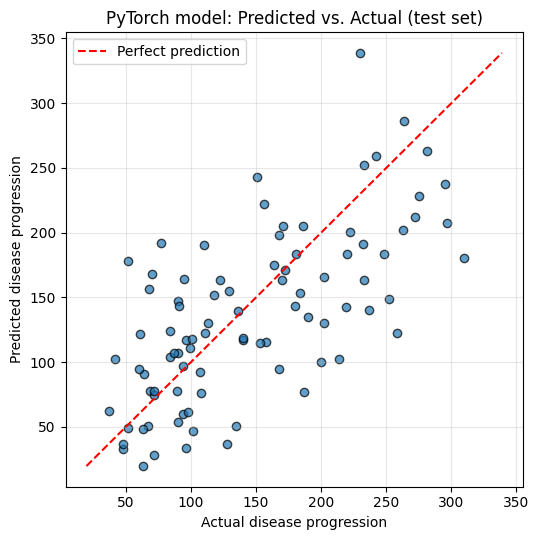

In [12]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(test_actual, test_preds, alpha=0.7, edgecolor="k")
lims = [min(test_actual.min(), test_preds.min()), max(test_actual.max(), test_preds.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual disease progression")
plt.ylabel("Predicted disease progression")
plt.title("PyTorch model: Predicted vs. Actual (test set)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Summary

- I trained a small PyTorch regression network — two fully connected layers (`Linear(10, 8) → ReLU → Linear(8, 1)`) — on scikit-learn's diabetes dataset, exactly meeting the required specification: **MSE loss**, **2 FC layers**, **batch size 8**, **SGD optimizer**, **1000 epochs**.
- Standardizing both the input features and the target was important for SGD to train smoothly at a reasonable learning rate; without it, the raw feature scales (e.g. blood pressure vs. a normalized BMI-like column) would make gradient descent far less stable.
- The training/test loss curves show the loss dropping quickly in the first ~100 epochs and then leveling off, which is the expected shape for a model that has essentially converged well before the full 1000 epochs are used.
- On the held-out test set, the network's test $R^2$ came out comparable to a classical linear regression baseline — which makes sense, since the diabetes dataset's relationship between features and target is largely linear to begin with, so adding a hidden ReLU layer offers only a modest advantage on this particular dataset.
- This exercise mirrors the earlier "PyTorch Components" walkthrough (input/target → `Dataset`/`DataLoader` → `nn.Linear` → loss → optimizer → training loop) but scales it up from a 3-input toy example (Lab 2/3) to a real dataset with proper train/test evaluation — the same core ideas, applied end-to-end.